## Import libraries and load the data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


OPTIONS = ["A", "B", "C", "D", "E"]

# Load the CSV files
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print("Train shape:", train.shape)   
print("Test shape :", test.shape)
print("Columns    :", list(train.columns))


train.head(2)


Train shape: (2000, 8)
Test shape : (500, 7)
Columns    : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A


In [3]:

row = train.iloc[0]

print("QUESTION:")
print(row["prompt"])
print()


for opt in OPTIONS:

    mark = "  <-- CORRECT" if opt == row["answer"] else ""
    print(f"[{opt}] {row[opt][:100]}...{mark}")


QUESTION:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

[A] Martin Heidegger believes that humans exist within a time continuum that is infinite and does not ha...
[B] Martin Heidegger believes that humans do not exist inside time, but that they are time. The relation...  <-- CORRECT
[C] Martin Heidegger does not believe in the existence of time or that it has any effect on human consci...
[D] Martin Heidegger believes that the relationship between time and human existence is cyclical. The pa...
[E] Martin Heidegger believes that time is an illusion, and the past, present, and future are all happen...


## Check for missing values


In [4]:

print("Missing values in train:")
print(train.isnull().sum())

print()
print("Total missing in train:", train.isnull().sum().sum())
print("Total missing in test :", test.isnull().sum().sum())


Missing values in train:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Total missing in train: 0
Total missing in test : 0


## Which answer label is most common?



Count of each correct answer:
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


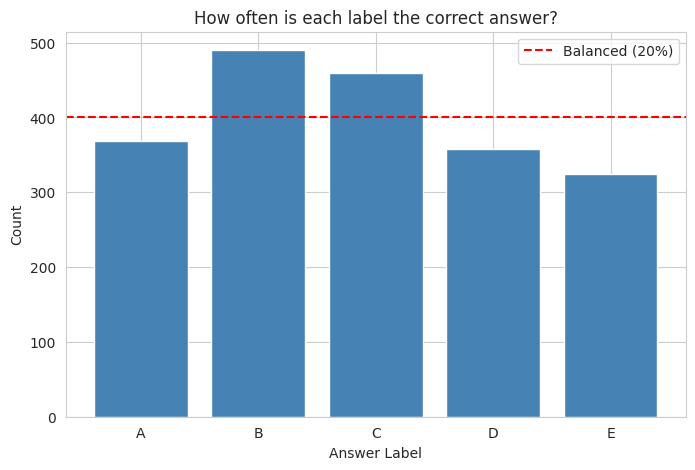


Observation: B and C appear more often than A, D, E.
This means there is a small 'positional bias' in the data.


In [7]:

answer_counts = train["answer"].value_counts()
answer_counts = answer_counts.reindex(OPTIONS)  

print("Count of each correct answer:")
print(answer_counts)


plt.figure(figsize=(8, 5))
plt.bar(OPTIONS, answer_counts.values, color="steelblue")


balanced = len(train) / 5
plt.axhline(balanced, color="red", linestyle="--", label="Balanced (20%)")

plt.title("How often is each label the correct answer?")
plt.xlabel("Answer Label")
plt.ylabel("Count")
plt.legend()
plt.show()

print("\nObservation: B and C appear more often than A, D, E.")
print("This means there is a small 'positional bias' in the data.")


## Are correct options longer than wrong options?


In [8]:

correct_lengths = []
wrong_lengths = []


for index, row in train.iterrows():
    for opt in OPTIONS:
       
        num_words = len(str(row[opt]).split())

       
        if opt == row["answer"]:
            correct_lengths.append(num_words)
        else:
            wrong_lengths.append(num_words)


print("Average words in CORRECT options:", round(np.mean(correct_lengths), 1))
print("Average words in WRONG options  :", round(np.mean(wrong_lengths), 1))


Average words in CORRECT options: 28.7
Average words in WRONG options  : 25.7


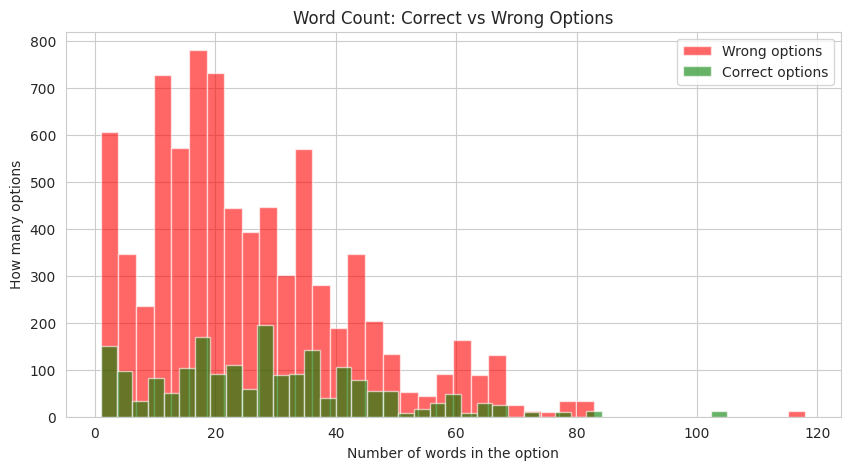

Observation: Correct options tend to be slightly LONGER.
A model could 'cheat' by just picking the longest option.


In [9]:

plt.figure(figsize=(10, 5))

plt.hist(wrong_lengths, bins=40, alpha=0.6, color="red", label="Wrong options")
plt.hist(correct_lengths, bins=40, alpha=0.6, color="green", label="Correct options")

plt.title("Word Count: Correct vs Wrong Options")
plt.xlabel("Number of words in the option")
plt.ylabel("How many options")
plt.legend()
plt.show()

print("Observation: Correct options tend to be slightly LONGER.")
print("A model could 'cheat' by just picking the longest option.")


## How often is the LONGEST option the correct one?


In [10]:

longest_is_correct = 0

for index, row in train.iterrows():
 
    lengths = [len(str(row[opt]).split()) for opt in OPTIONS]

   
    longest_index = np.argmax(lengths)
    longest_option = OPTIONS[longest_index]

    if longest_option == row["answer"]:
        longest_is_correct += 1


percentage = longest_is_correct / len(train) * 100

print(f"Longest option is correct: {longest_is_correct} times out of {len(train)}")
print(f"That is {percentage:.1f}% (random would be 20%)")
print()
print("Conclusion: The 'pick the longest' trick works much better than random.")
print("This is a data artifact we must handle during training.")


Longest option is correct: 699 times out of 2000
That is 34.9% (random would be 20%)

Conclusion: The 'pick the longest' trick works much better than random.
This is a data artifact we must handle during training.


## How long are the questions?



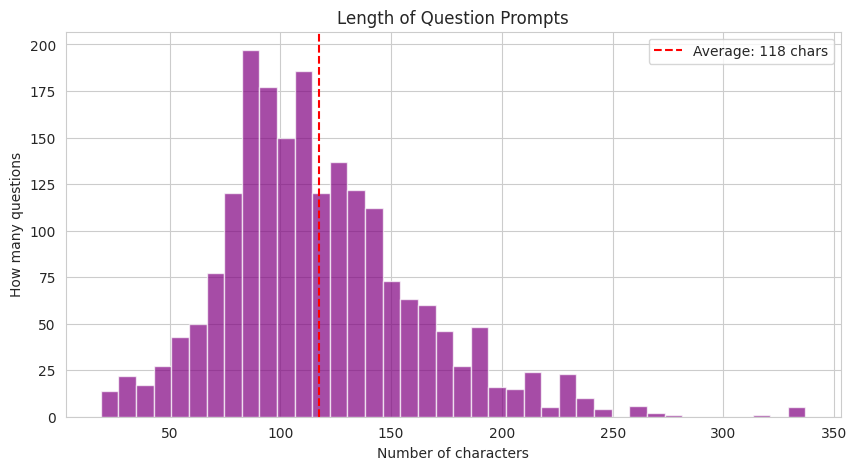

Shortest prompt: 19 characters
Longest prompt : 337 characters
Average prompt : 118 characters


In [11]:

prompt_lengths = train["prompt"].str.len()

plt.figure(figsize=(10, 5))
plt.hist(prompt_lengths, bins=40, color="purple", alpha=0.7)
plt.axvline(prompt_lengths.mean(), color="red", linestyle="--",
            label=f"Average: {prompt_lengths.mean():.0f} chars")
plt.title("Length of Question Prompts")
plt.xlabel("Number of characters")
plt.ylabel("How many questions")
plt.legend()
plt.show()

print("Shortest prompt:", prompt_lengths.min(), "characters")
print("Longest prompt :", prompt_lengths.max(), "characters")
print("Average prompt :", round(prompt_lengths.mean()), "characters")


## What topics are in the data?



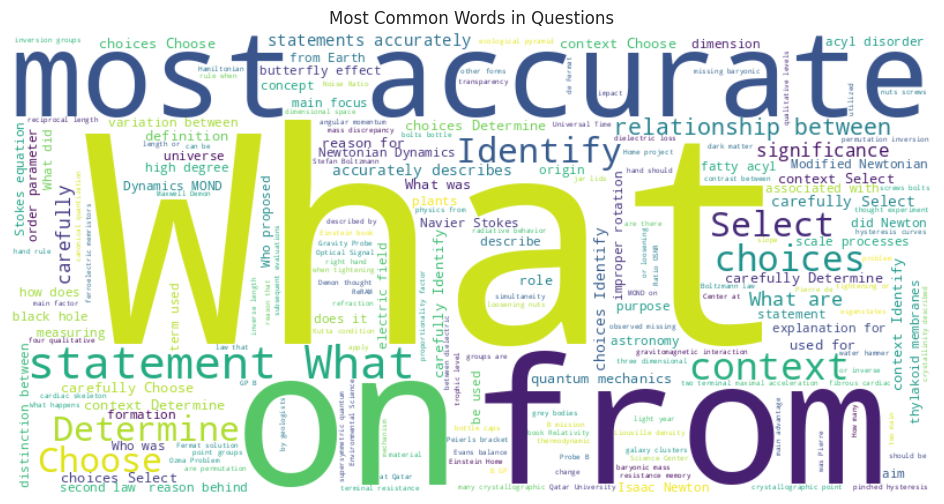

In [12]:

boring_words = {"pick", "best", "possible", "answer", "following", "correct",
                "option", "the", "is", "a", "an", "of", "to", "and", "in",
                "among", "listed", "options", "which", "based", "given"}


all_prompts = " ".join(train["prompt"].tolist())


wordcloud = WordCloud(width=800, height=400,
                      background_color="white",
                      stopwords=boring_words,
                      colormap="viridis").generate(all_prompts)


plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Questions")
plt.show()


## Do train and test share any questions?


In [13]:

train_prompts = set(train["prompt"])
test_prompts = set(test["prompt"])

shared_prompts = train_prompts.intersection(test_prompts)

print("Unique prompts in train:", len(train_prompts))
print("Unique prompts in test :", len(test_prompts))
print("Prompts in BOTH         :", len(shared_prompts))
print()
print(f"That means {len(shared_prompts)/len(test)*100:.1f}% of test questions are also in train.")


Unique prompts in train: 1758
Unique prompts in test : 492
Prompts in BOTH         : 267

That means 53.4% of test questions are also in train.


In [14]:

correct_answer_text = {}
for index, row in train.iterrows():
    prompt = row["prompt"]
    answer_text = row[row["answer"]]  
    correct_answer_text[prompt] = answer_text


matches = 0
for index, row in test.iterrows():
    prompt = row["prompt"]
    if prompt in correct_answer_text:
        known_answer = correct_answer_text[prompt]

        test_options = [row[opt] for opt in OPTIONS]
        if known_answer in test_options:
            matches += 1

print(f"Test rows where we already know the answer from train: {matches}")
print(f"That is {matches/len(test)*100:.1f}% of the test set.")
print()
print("Conclusion: We can directly look up the answer for these rows!")


Test rows where we already know the answer from train: 262
That is 52.4% of the test set.

Conclusion: We can directly look up the answer for these rows!


## Summary of Findings


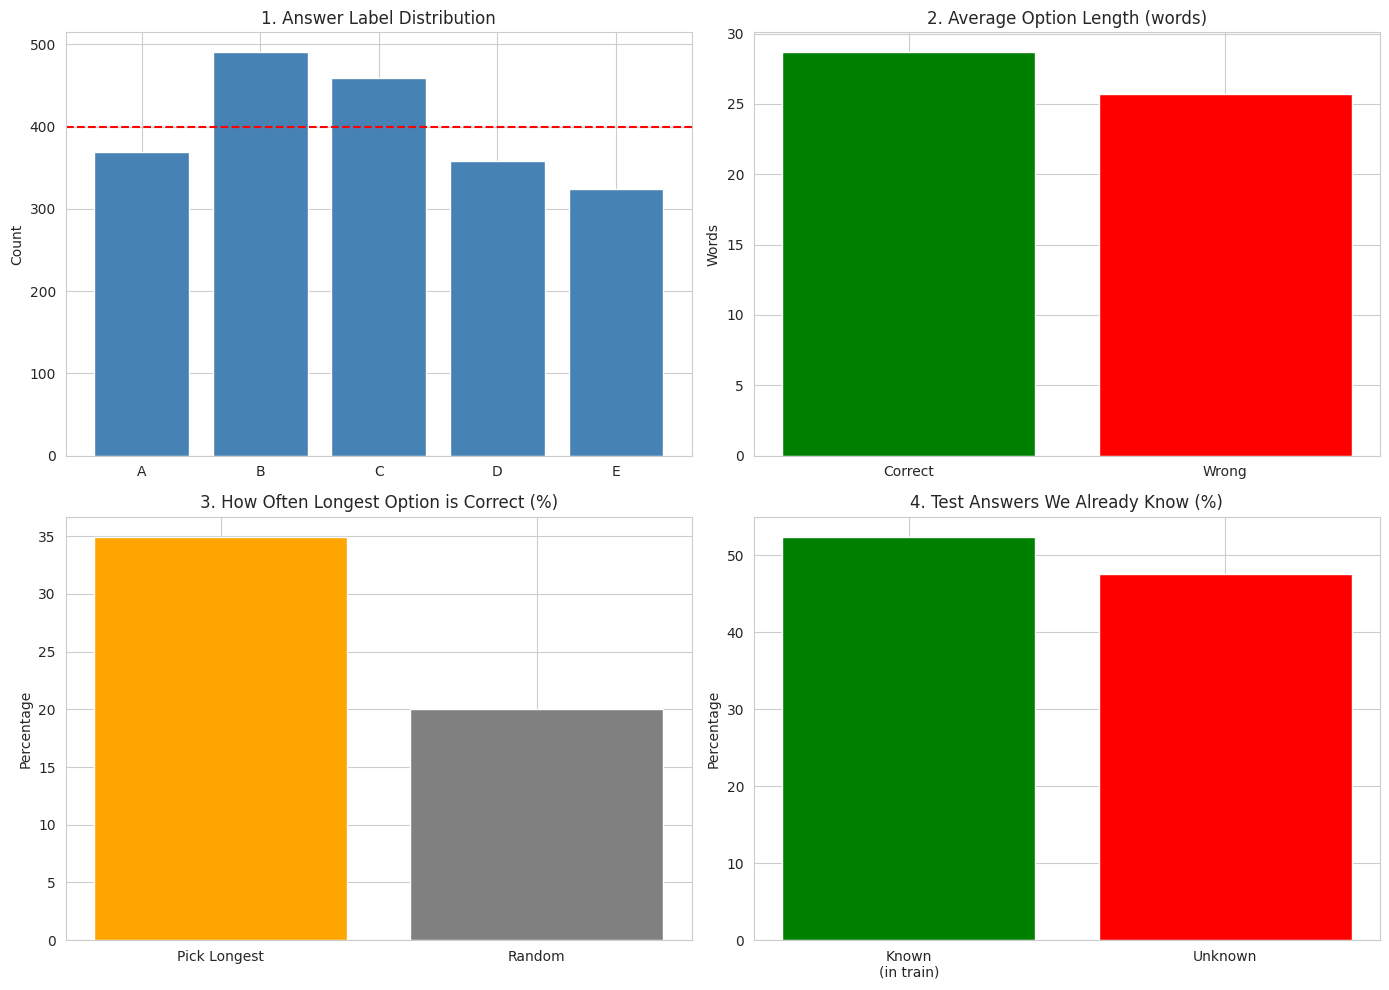

In [15]:

avg_correct = np.mean(correct_lengths)
avg_wrong = np.mean(wrong_lengths)
longest_pct = longest_is_correct / len(train) * 100
overlap_pct = len(shared_prompts) / len(test) * 100
lookup_pct = matches / len(test) * 100


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Answer distribution
axes[0, 0].bar(OPTIONS, answer_counts.values, color="steelblue")
axes[0, 0].axhline(len(train)/5, color="red", linestyle="--")
axes[0, 0].set_title("1. Answer Label Distribution")
axes[0, 0].set_ylabel("Count")

# Plot 2: Correct vs wrong length
axes[0, 1].bar(["Correct", "Wrong"], [avg_correct, avg_wrong],
               color=["green", "red"])
axes[0, 1].set_title("2. Average Option Length (words)")
axes[0, 1].set_ylabel("Words")

# Plot 3: Longest option correct rate
axes[1, 0].bar(["Pick Longest", "Random"], [longest_pct, 20],
               color=["orange", "gray"])
axes[1, 0].set_title("3. How Often Longest Option is Correct (%)")
axes[1, 0].set_ylabel("Percentage")

# Plot 4: Train-test overlap
axes[1, 1].bar(["Known\n(in train)", "Unknown"],
               [lookup_pct, 100 - lookup_pct],
               color=["green", "red"])
axes[1, 1].set_title("4. Test Answers We Already Know (%)")
axes[1, 1].set_ylabel("Percentage")

plt.tight_layout()
plt.show()


In [16]:

print("="*55)
print("           EDA SUMMARY - KEY FINDINGS")
print("="*55)
print()
print(f"1. Dataset: {len(train)} train rows, {len(test)} test rows")
print(f"2. Labels B and C are most common as correct answers")
print(f"3. Correct options are longer: {avg_correct:.0f} words vs {avg_wrong:.0f} words")
print(f"4. Longest option is correct {longest_pct:.0f}% of time (random = 20%)")
print(f"5. {overlap_pct:.0f}% of test questions also appear in train")
print(f"6. We can directly look up {lookup_pct:.0f}% of test answers")
print()
print("="*55)
print("        WHAT THIS MEANS FOR THE MODEL")
print("="*55)
print()
print("- Shuffle option order during training (fixes B/C bias)")
print("- Cut all options to same length (fixes length cheat)")
print("- Use lookup for known answers (free correct predictions)")
print("- Group same prompts together in cross-validation")


           EDA SUMMARY - KEY FINDINGS

1. Dataset: 2000 train rows, 500 test rows
2. Labels B and C are most common as correct answers
3. Correct options are longer: 29 words vs 26 words
4. Longest option is correct 35% of time (random = 20%)
5. 53% of test questions also appear in train
6. We can directly look up 52% of test answers

        WHAT THIS MEANS FOR THE MODEL

- Shuffle option order during training (fixes B/C bias)
- Cut all options to same length (fixes length cheat)
- Use lookup for known answers (free correct predictions)
- Group same prompts together in cross-validation
